<a href="https://colab.research.google.com/github/Harshitprajapati10/dl-lab-2026/blob/main/question_01_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### load the mnist dataset using torchvision
### normalize the input data by scaling pixel values to the range [0,1]

In [1]:
!pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 70.9 MB/s eta 0:00:00


In [37]:
from datasets import load_dataset
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torch.utils.data import DataLoader
import pytorch_lightning as L
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
dataset = load_dataset("mnist")
dataset


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mnist/train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

mnist/test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [4]:
train_dataset = dataset["train"]
test_dataset = dataset["test"]

In [5]:
split = train_dataset.train_test_split(test_size=0.1,seed=42)
train_dataset = split["train"]
valid_dataset = split["test"]

In [6]:
train_dataset.shape, valid_dataset.shape, test_dataset.shape

((54000, 2), (6000, 2), (10000, 2))

In [7]:
def normalize(data):
    data["image"] = np.array(data["image"], dtype=np.float32) / 255.0
    return data

In [8]:
train_dataset = train_dataset.map(normalize)
valid_dataset = valid_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)

Map:   0%|          | 0/54000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [30]:
print("Train:", len(train_dataset))
print("Validation:", len(valid_dataset))
print("Test:", len(test_dataset))

Train: 54000
Validation: 6000
Test: 10000


In [31]:
train_dataset.set_format(type="torch", columns=["image", "label"])
valid_dataset.set_format(type="torch", columns=["image", "label"])
test_dataset.set_format(type="torch", columns=["image", "label"])

In [32]:
## dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

### creating the model

In [33]:
class MNISTmodel(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )

        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self,x):
        return self.model(x)

    def training_step(self,batch,batch_idx):
        x,y = batch["image"], batch["label"]
        y_hat = self(x)

        loss = self.loss_fn(y_hat,y)
        preds = torch.argmax(y_hat,dim=1)
        acc = (preds==y).float().mean()

        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self,batch,batch_idx):

        x,y = batch["image"], batch["label"]
        y_hat = self(x)

        loss = self.loss_fn(y_hat,y)

        preds = torch.argmax(y_hat,dim=1)
        acc = (preds==y).float().mean()

        self.log("val_loss",loss,on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_acc",acc, on_step=False, on_epoch=True, prog_bar=True)


    def test_step(self,batch,batch_idx):

        x,y = batch["image"], batch["label"]
        y_hat = self(x)

        loss = self.loss_fn(y_hat,y)

        preds = torch.argmax(y_hat,dim=1)
        acc = (preds==y).float().mean()

        self.log("test_loss",loss)
        self.log("test_acc",acc)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(),lr=0.001)


In [34]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    mode="min"
)
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    filename="mnist-model-best",
    save_top_k=1,
    mode="min"
)

logger = CSVLogger("logs", name="mnist") ## log the loss, acc

trainer = L.Trainer(
    max_epochs=10,
    callbacks=[early_stop, checkpoint_callback]
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [35]:
model = MNISTmodel()

In [36]:
trainer.fit(model,train_loader, val_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential       │  109 K │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 109 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 109 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

### save and load the model on test dataset

In [38]:
model = MNISTmodel.load_from_checkpoint(
    "./lightning_logs/version_0/checkpoints/mnist-model-best.ckpt"
)

model.eval()

MNISTmodel(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
  (loss_fn): CrossEntropyLoss()
)

In [39]:
model = model.to("cuda")

In [40]:
trainer.test(model, dataloaders=test_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9769999980926514     │
│         test_loss         │    0.07433849573135376    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.07433849573135376, 'test_acc': 0.9769999980926514}]

In [41]:
batch = next(iter(test_loader))

images = batch["image"]
labels = batch["label"]

with torch.no_grad():
    outputs = model(images)

preds = torch.argmax(outputs, dim=1)

In [42]:
print("Predicted:", preds[:2])
print("Actual:", labels[:2])

Predicted: tensor([7, 2])
Actual: tensor([7, 2])


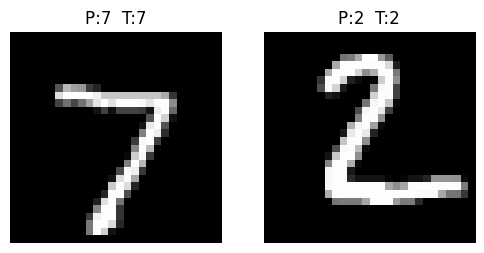

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))

for i in range(2):

    plt.subplot(1,2,i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"P:{preds[i].item()}  T:{labels[i].item()}")
    plt.axis("off")

plt.show()

### Plot loss curves

In [46]:
logger = CSVLogger("logs", name="mnist")